# SHAP Explainability — Structured Soil Models

This notebook applies SHAP (SHapley Additive exPlanations) to the trained
Gradient Boosting models for nitrogen (N), phosphorus (P), and potassium (K)
deficiency prediction.

## Objectives

- Load the trained N, P, and K Gradient Boosting models
- Generate SHAP explanations using TreeExplainer
- Identify globally influential features for each nutrient model
- Generate local explanations for individual deficiency predictions
- Visualize feature contributions using SHAP summary and waterfall plots
- Interpret model behavior while distinguishing model explanation from
  causal relationships

The models and feature sets used here are the same final models produced in
the structured machine-learning notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Raw/Structured_Data/Crop_recommendationV2.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2200, 23)


,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


In [ ]:
feature_columns = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall",
    "soil_moisture",
    "soil_type",
    "sunlight_exposure",
    "wind_speed",
    "co2_concentration",
    "organic_matter",
    "irrigation_frequency",
    "crop_density",
    "pest_pressure",
    "fertilizer_usage",
    "growth_stage",
    "urban_area_proximity",
    "water_source_type",
    "frost_risk",
    "water_usage_efficiency"
]

print("Number of candidate features:", len(feature_columns))

Number of candidate features: 22


In [ ]:
X_N = df[[col for col in feature_columns if col != "N"]]
X_P = df[[col for col in feature_columns if col != "P"]]
X_K = df[[col for col in feature_columns if col != "K"]]

print("N model features:", X_N.shape)
print("P model features:", X_P.shape)
print("K model features:", X_K.shape)

N model features: (2200, 21)
P model features: (2200, 21)
K model features: (2200, 21)


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/Soil_Analytics_Project/Models"

N_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "N_deficiency_gradient_boosting.pkl"
)

P_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "P_deficiency_gradient_boosting.pkl"
)

K_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "K_deficiency_gradient_boosting.pkl"
)

model_N = joblib.load(N_MODEL_PATH)
model_P = joblib.load(P_MODEL_PATH)
model_K = joblib.load(K_MODEL_PATH)

print("N model loaded:", type(model_N).__name__)
print("P model loaded:", type(model_P).__name__)
print("K model loaded:", type(model_K).__name__)

N model loaded: GradientBoostingClassifier
P model loaded: GradientBoostingClassifier
K model loaded: GradientBoostingClassifier


In [ ]:
explainer_N = shap.TreeExplainer(model_N)

print("N SHAP explainer created successfully.")

N SHAP explainer created successfully.


In [ ]:
shap_values_N = explainer_N(X_N)

print("SHAP values generated.")
print("Shape:", shap_values_N.values.shape)

SHAP values generated.
Shape: (2200, 21)


## How to Interpret the SHAP Summary Plot

The SHAP summary plot provides a global view of feature influence across the
dataset.

- Features are ordered by their average absolute SHAP contribution.
- Each point represents one sample.
- The horizontal position indicates whether the feature pushes the model
  output higher or lower.
- The magnitude of the SHAP value indicates the strength of the contribution.
- Feature color represents the relative feature value, from lower to higher
  values.

The plot describes how features influence the trained model's predictions;
it does not establish that a feature causes nutrient deficiency.

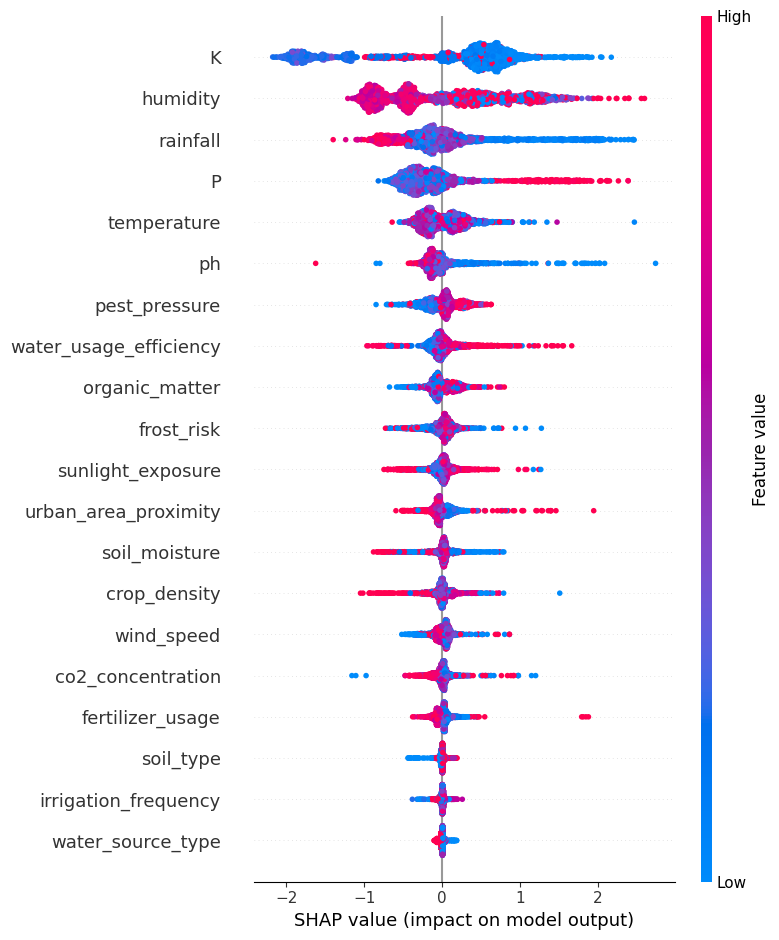

In [ ]:
shap.summary_plot(
    shap_values_N.values,
    X_N,
    show=True
)

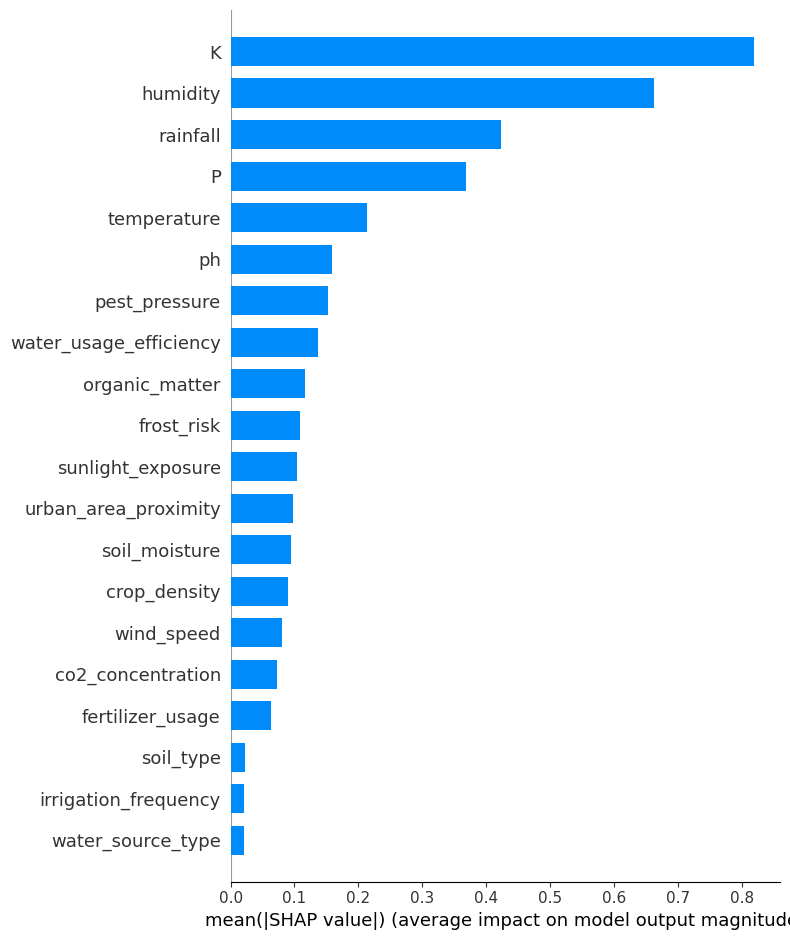

In [ ]:
shap.summary_plot(
    shap_values_N.values,
    X_N,
    plot_type="bar",
    show=True
)

In [ ]:
pred_N = model_N.predict(X_N)

deficient_indices = np.where(pred_N == 1)[0]

print("Number of predicted N-deficient samples:", len(deficient_indices))
print("Example sample index:", deficient_indices[0])

Number of predicted N-deficient samples: 502
Example sample index: 254


In [ ]:
sample_index = deficient_indices[0]

print("Predicted class:", model_N.predict(X_N.iloc[[sample_index]])[0])
print("Predicted probability:", model_N.predict_proba(X_N.iloc[[sample_index]])[0])

Predicted class: 1
Predicted probability: [0.23499099 0.76500901]


## How to Interpret a SHAP Waterfall Plot

A SHAP waterfall plot explains one individual prediction.

Starting from the model's baseline output, each feature contributes either
positively or negatively to the model output for that specific sample.

Positive SHAP contributions push the prediction toward the modeled positive
class, while negative contributions push it away from that class.

The waterfall plot therefore provides a local explanation of the model's
decision rather than a causal explanation of the underlying soil process.

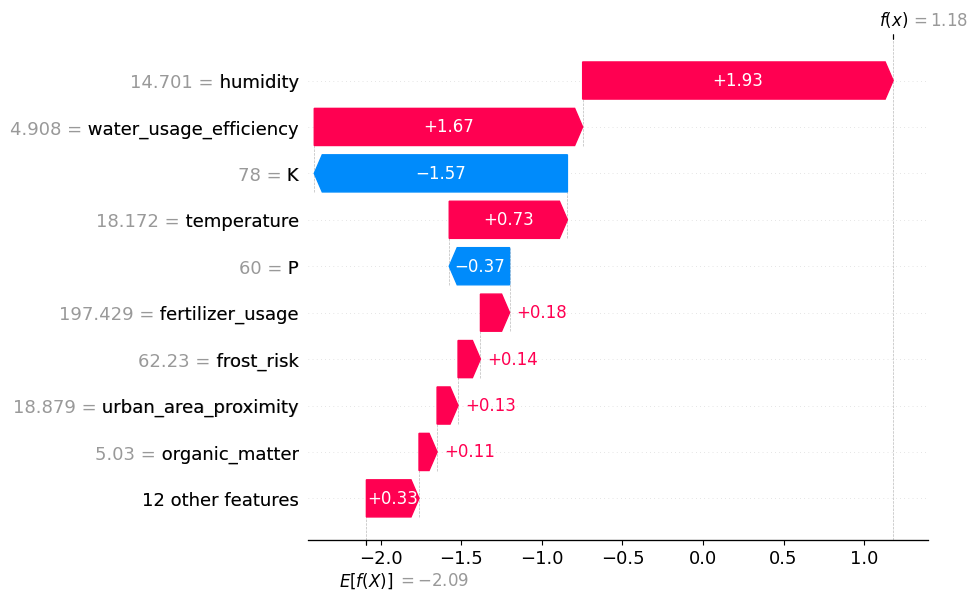

In [ ]:
shap.plots.waterfall(
    shap_values_N[sample_index],
    max_display=10
)

In [ ]:
explainer_P = shap.TreeExplainer(model_P)

print("P SHAP explainer created successfully.")

P SHAP explainer created successfully.


In [ ]:
shap_values_P = explainer_P(X_P)

print("P SHAP values generated.")
print("Shape:", shap_values_P.values.shape)

P SHAP values generated.
Shape: (2200, 21)


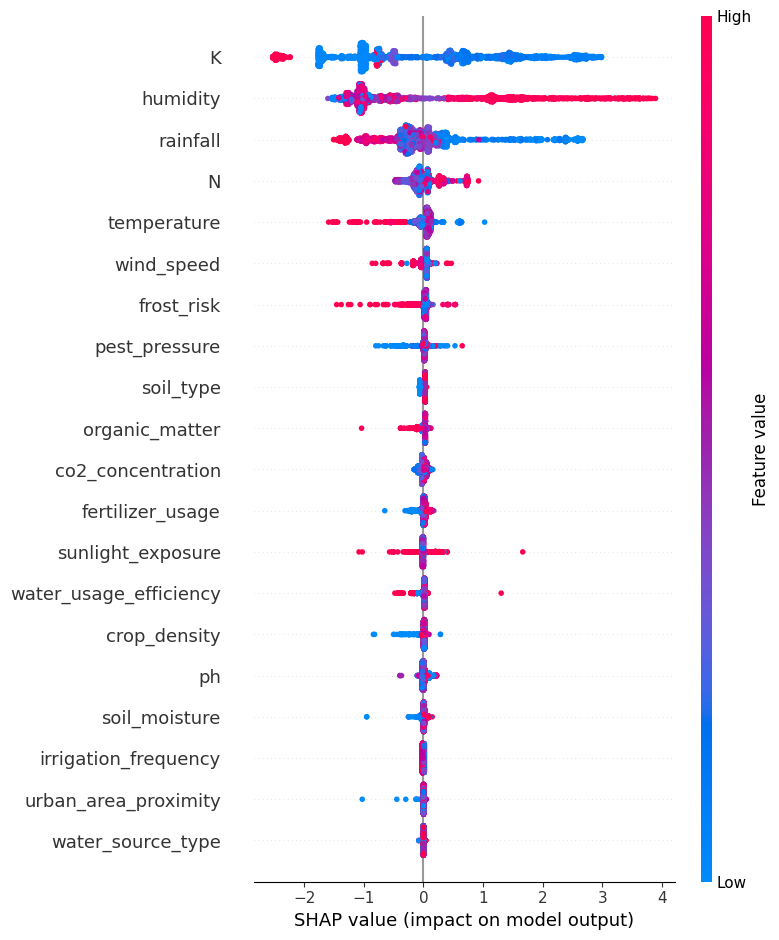

In [ ]:
shap.summary_plot(
    shap_values_P.values,
    X_P,
    show=True
)

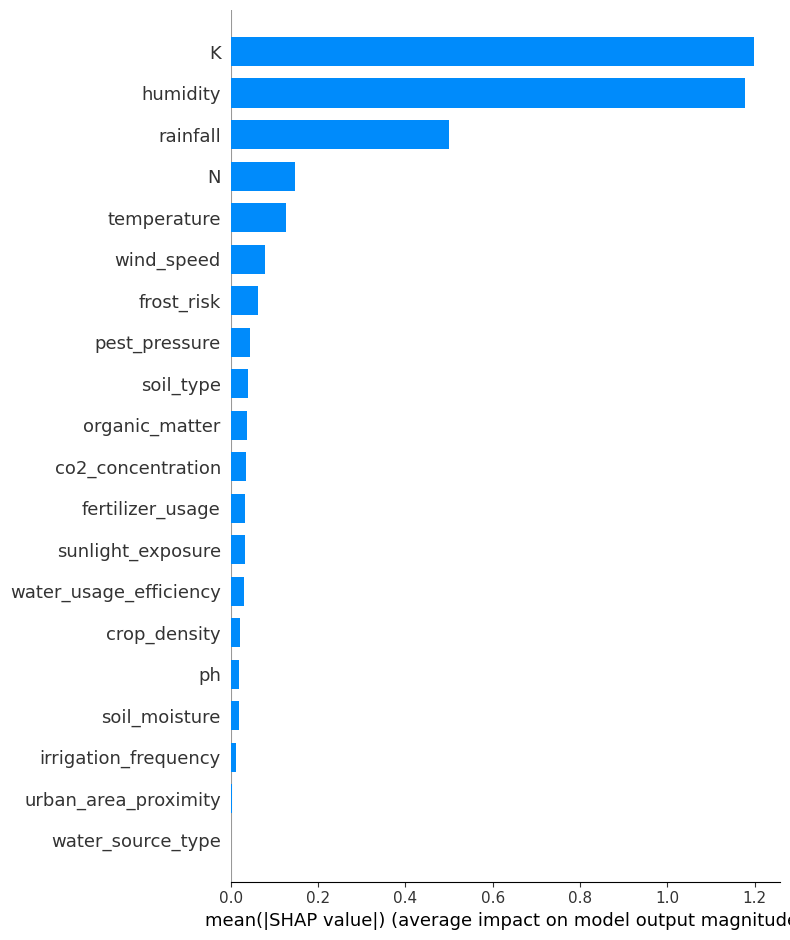

In [ ]:
shap.summary_plot(
    shap_values_P.values,
    X_P,
    plot_type="bar",
    show=True
)

In [ ]:
pred_P = model_P.predict(X_P)

deficient_indices_P = np.where(pred_P == 1)[0]

print("Number of predicted P-deficient samples:", len(deficient_indices_P))
print("Example sample index:", deficient_indices_P[0])

Number of predicted P-deficient samples: 561
Example sample index: 900


In [ ]:
sample_index_P = deficient_indices_P[0]

print("Predicted class:", model_P.predict(X_P.iloc[[sample_index_P]])[0])
print("Predicted probability:", model_P.predict_proba(X_P.iloc[[sample_index_P]])[0])

Predicted class: 1
Predicted probability: [0.14140475 0.85859525]


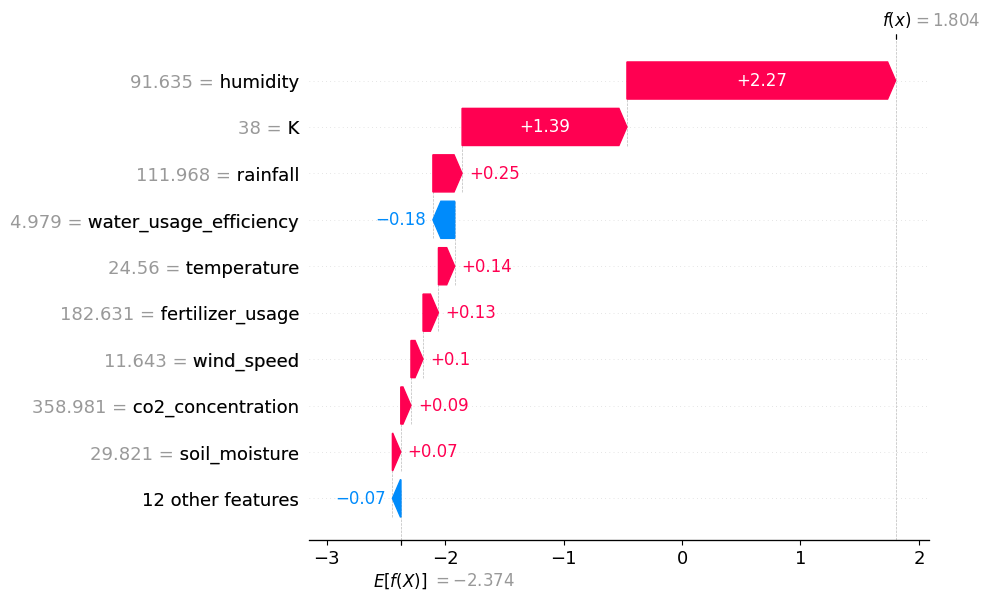

In [ ]:
shap.plots.waterfall(
    shap_values_P[sample_index_P],
    max_display=10
)

In [ ]:
explainer_K = shap.TreeExplainer(model_K)

print("K SHAP explainer created successfully.")

K SHAP explainer created successfully.


In [ ]:
shap_values_K = explainer_K(X_K)

print("K SHAP values generated.")
print("Shape:", shap_values_K.values.shape)

K SHAP values generated.
Shape: (2200, 21)


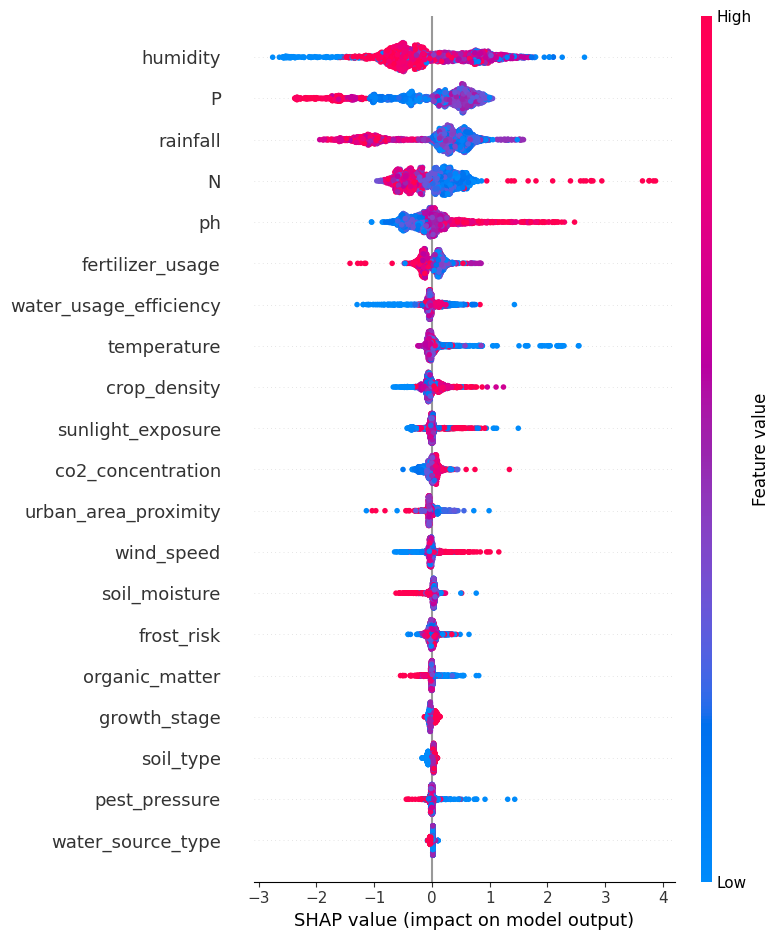

In [ ]:
shap.summary_plot(
    shap_values_K.values,
    X_K,
    show=True
)

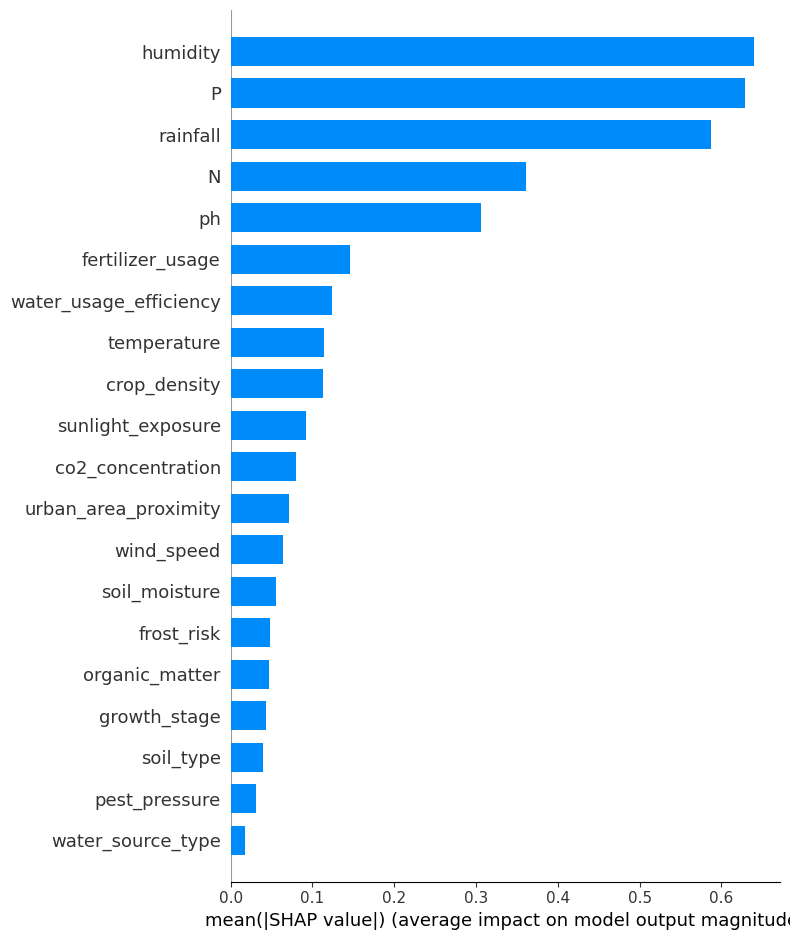

In [ ]:
shap.summary_plot(
    shap_values_K.values,
    X_K,
    plot_type="bar",
    show=True
)

In [ ]:
pred_K = model_K.predict(X_K)

deficient_indices_K = np.where(pred_K == 1)[0]

print("Number of predicted K-deficient samples:", len(deficient_indices_K))
print("Example sample index:", deficient_indices_K[0])

Number of predicted K-deficient samples: 427
Example sample index: 100


### Important Interpretation Note

The local examples are selected using the model's predicted deficiency class.
Therefore, the SHAP waterfall plots explain why the model produced those
predictions. They do not independently verify whether the underlying soil
sample is genuinely nutrient deficient.

In [ ]:
sample_index_K = deficient_indices_K[0]

print("Predicted class:", model_K.predict(X_K.iloc[[sample_index_K]])[0])
print("Predicted probability:", model_K.predict_proba(X_K.iloc[[sample_index_K]])[0])

Predicted class: 1
Predicted probability: [0.38367097 0.61632903]


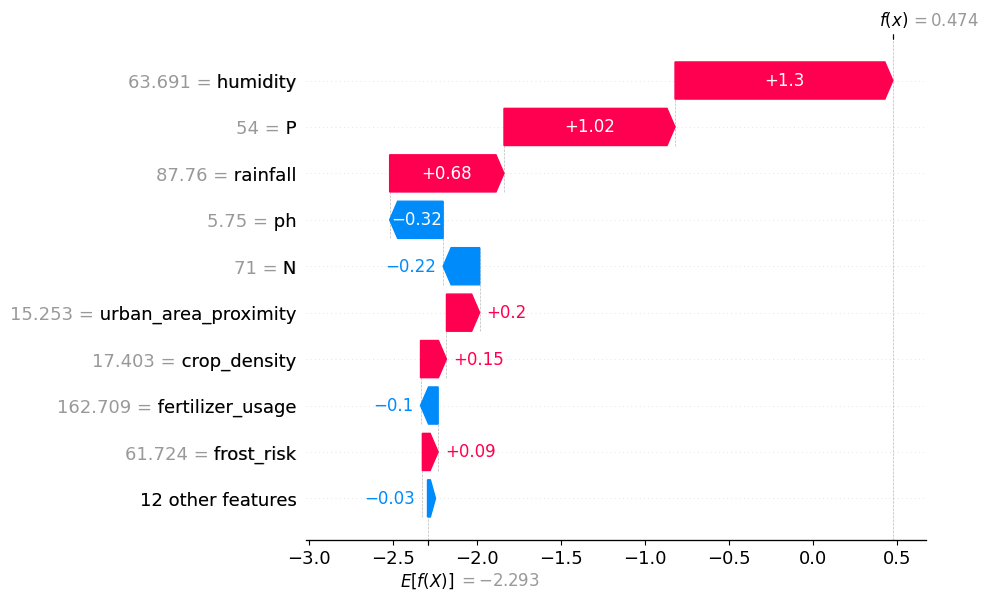

In [ ]:
shap.plots.waterfall(
    shap_values_K[sample_index_K],
    max_display=10
)

## SHAP Explainability Summary

SHAP (SHapley Additive exPlanations) was used to interpret the
Gradient Boosting models for nitrogen, phosphorus, and potassium
deficiency prediction.

Global SHAP analysis identified the features that had the greatest
average influence on each nutrient-deficiency model. Local SHAP
waterfall plots were also generated to explain individual model
predictions.

For the N-deficiency model, K, humidity, rainfall, P, and temperature
were among the most influential features.

For the P-deficiency model, K, humidity, rainfall, N, and temperature
were among the most influential features.

For the K-deficiency model, humidity, P, rainfall, N, and pH were
among the most influential features.

These SHAP results explain model behavior and should not be interpreted
as evidence of causal relationships. The deficiency targets used in
this project are dataset-derived proxy labels rather than laboratory-
confirmed nutrient deficiency measurements.

The SHAP explanations are generated from the final saved Gradient Boosting
models and use the same feature representations used during model training.